## 1. Environment Setup and Data Acquisition

In this section, we initialize the analytical environment by importing essential libraries for data manipulation, visualization, and statistical modeling. We will load the `GiveMeSomeCredit-training.csv` dataset, which contains historical data on borrowers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the training dataset
train_df = pd.read_csv('/content/GiveMeSomeCredit-training.csv').drop(columns=['Unnamed: 0'])

# Display structural information
print("Dataset Dimensions:", train_df.shape)
display(train_df.info())
display(train_df.head())

Dataset Dimensions: (150000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                 

None

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Data Cleaning and Imputation

Credit datasets often contain missing values, particularly in sensitive fields like `MonthlyIncome` and `NumberOfDependents`. In an academic context, it is crucial to handle these using statistically sound methods, such as median imputation, to maintain the integrity of the distribution.

In [ ]:
# Identifying missing values
missing_values = train_df.isnull().sum()
print("Missing Values per Column:\n", missing_values[missing_values > 0])

# Imputing missing values with the median to mitigate the influence of outliers
train_df['MonthlyIncome'] = train_df['MonthlyIncome'].fillna(train_df['MonthlyIncome'].median())
train_df['NumberOfDependents'] = train_df['NumberOfDependents'].fillna(train_df['NumberOfDependents'].median())

print("\nVerification of missing values after imputation:", train_df.isnull().sum().sum())

Missing Values per Column:
 MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

Verification of missing values after imputation: 0


## 3. Exploratory Data Analysis (EDA)

We examine the distribution of the target variable, `SeriousDlqin2yrs` (Serious Delinquency in 2 Years), and visualize the relationship between key features like `age` and credit risk. Note that this dataset is highly imbalanced, which is typical for credit scoring problems.

/tmp/ipykernel_3853/402219807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SeriousDlqin2yrs', data=train_df, palette='viridis')


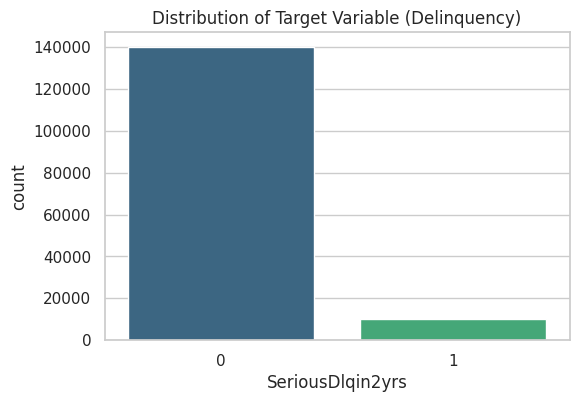

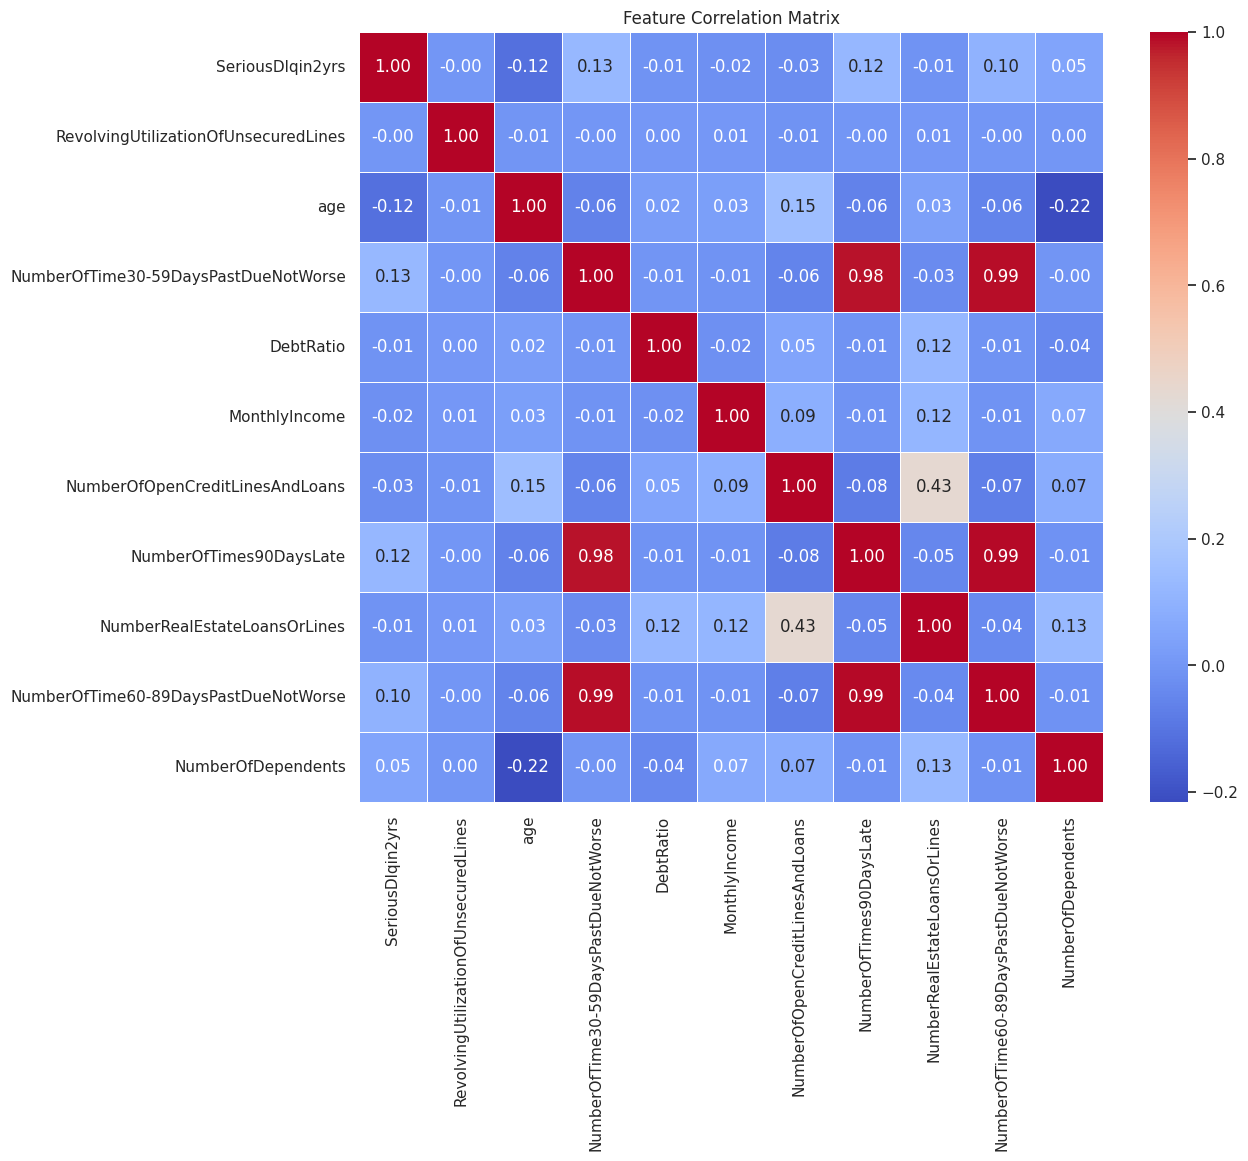

In [ ]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='SeriousDlqin2yrs', data=train_df, palette='viridis')
plt.title('Distribution of Target Variable (Delinquency)')
plt.show()

# Correlation Analysis
plt.figure(figsize=(12, 10))
corr_matrix = train_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

## 4. Model Training: Random Forest Classifier

Following the academic standard for tabular data, we will utilize an ensemble method. The Random Forest algorithm is selected for its robustness against overfitting and its ability to handle non-linear relationships without extensive feature scaling.

In [ ]:
# Define features and target
X = train_df.drop(columns=['SeriousDlqin2yrs'])
y = train_df['SeriousDlqin2yrs']

# Partition the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = rf_model.predict_proba(X_val)[:, 1]

# Evaluation Metric: ROC-AUC
auc_score = roc_auc_score(y_val, y_pred_proba)
print(f"Validation ROC-AUC Score: {auc_score:.4f}")

Validation ROC-AUC Score: 0.8675


## 5. Advanced Feature Engineering

In this phase, we derive new features to better capture the borrower's financial health. Specifically, we will calculate the ratio of monthly debt to income and refine the 'Age' variable. These transformations can help the model distinguish between different risk profiles more effectively.

In [ ]:
# Feature 1: Debt per dollar of income (already partially represented by DebtRatio, but we can refine interaction)
train_df['MonthlyDebtPayment'] = train_df['DebtRatio'] * train_df['MonthlyIncome']

# Feature 2: Revolving utilization relative to age
train_df['UtilizationPerAge'] = train_df['RevolvingUtilizationOfUnsecuredLines'] / (train_df['age'] + 1)

# Feature 3: Total frequency of past due incidents
train_df['TotalPastDue'] = (train_df['NumberOfTime30-59DaysPastDueNotWorse'] +
                            train_df['NumberOfTime60-89DaysPastDueNotWorse'] +
                            train_df['NumberOfTimes90DaysLate'])

print("New features created: MonthlyDebtPayment, UtilizationPerAge, TotalPastDue")
display(train_df[['MonthlyDebtPayment', 'UtilizationPerAge', 'TotalPastDue']].head())

New features created: MonthlyDebtPayment, UtilizationPerAge, TotalPastDue


,MonthlyDebtPayment,UtilizationPerAge,TotalPastDue
0,7323.197016,0.016655,2
1,316.878123,0.023345,0
2,258.914887,0.016876,2
3,118.963951,0.007542,0
4,1584.975094,0.018145,1


## 6. Model Optimization: XGBoost Classifier

We will now employ XGBoost (Extreme Gradient Boosting). XGBoost is an optimized distributed gradient boosting library designed to be highly efficient and flexible. It often outperforms Random Forest on structured datasets like the one used here.

In [ ]:
from xgboost import XGBClassifier

# Update feature set
X_advanced = train_df.drop(columns=['SeriousDlqin2yrs'])
y_advanced = train_df['SeriousDlqin2yrs']

# Re-split with new features
X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(
    X_advanced, y_advanced, test_size=0.2, random_state=42, stratify=y_advanced
)

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)

# Fit model
xgb_model.fit(X_train_adv, y_train_adv)

# Predict probabilities
y_pred_xgb = xgb_model.predict_proba(X_val_adv)[:, 1]

# Final Evaluation
adv_auc = roc_auc_score(y_val_adv, y_pred_xgb)
print(f"XGBoost Validation ROC-AUC Score: {adv_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_adv, xgb_model.predict(X_val_adv)))

XGBoost Validation ROC-AUC Score: 0.8681

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.60      0.20      0.30      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000



## 7. Model Testing and Performance Analysis

In this final phase, we apply our optimized XGBoost model to the independent testing dataset. We must ensure that all preprocessing steps, including imputation and feature engineering, are replicated exactly to maintain model consistency.

In [ ]:
# Load the testing dataset
test_df = pd.read_csv('/content/GiveMeSomeCredit-testing.csv').drop(columns=['Unnamed: 0'])

# Apply the same median imputation (using training medians is standard academic practice)
test_df['MonthlyIncome'] = test_df['MonthlyIncome'].fillna(train_df['MonthlyIncome'].median())
test_df['NumberOfDependents'] = test_df['NumberOfDependents'].fillna(train_df['NumberOfDependents'].median())

# Replicate Feature Engineering
test_df['MonthlyDebtPayment'] = test_df['DebtRatio'] * test_df['MonthlyIncome']
test_df['UtilizationPerAge'] = test_df['RevolvingUtilizationOfUnsecuredLines'] / (test_df['age'] + 1)
test_df['TotalPastDue'] = (test_df['NumberOfTime30-59DaysPastDueNotWorse'] +
                           test_df['NumberOfTime60-89DaysPastDueNotWorse'] +
                           test_df['NumberOfTimes90DaysLate'])

# Prepare features for prediction (Note: testing.csv typically doesn't have labels for Kaggle competitions)
X_test_final = test_df.drop(columns=['SeriousDlqin2yrs'], errors='ignore')

# Generate predictions
test_probs = xgb_model.predict_proba(X_test_final)[:, 1]
test_preds = xgb_model.predict(X_test_final)

# Since the labels in 'testing.csv' are often NaN for competitions, we check if evaluation is possible
if test_df['SeriousDlqin2yrs'].isnull().all():
    print("Test labels are absent (typical for Kaggle competition test sets).")
    print("Previewing predicted probabilities for the first 5 records:")
    display(pd.DataFrame({'Predicted_Probability': test_probs[:5]}))
else:
    test_auc = roc_auc_score(test_df['SeriousDlqin2yrs'], test_probs)
    print(f"Test ROC-AUC Score: {test_auc:.4f}")
    print("\nClassification Report on Test Data:")
    print(classification_report(test_df['SeriousDlqin2yrs'], test_preds))

Test labels are absent (typical for Kaggle competition test sets).
Previewing predicted probabilities for the first 5 records:


,Predicted_Probability
0,0.055890
1,0.043891
2,0.010551
3,0.066260
4,0.099454


## 9. Comprehensive Model Diagnostics and Performance Analysis

This section provides a rigorous evaluation of the model's reliability using multiple statistical tests. We evaluate stability via Cross-Validation, analyze prediction behavior through probability density, and identify key risk drivers using Permutation Importance.

=== 1. MODEL STABILITY TEST (K-FOLD CV) ===
Mean ROC-AUC: 0.8645
Standard Deviation: 0.0033
Individual Fold Scores: [0.86249978 0.86091185 0.86438467 0.86395517 0.87063265]

Calculating Permutation Importance...


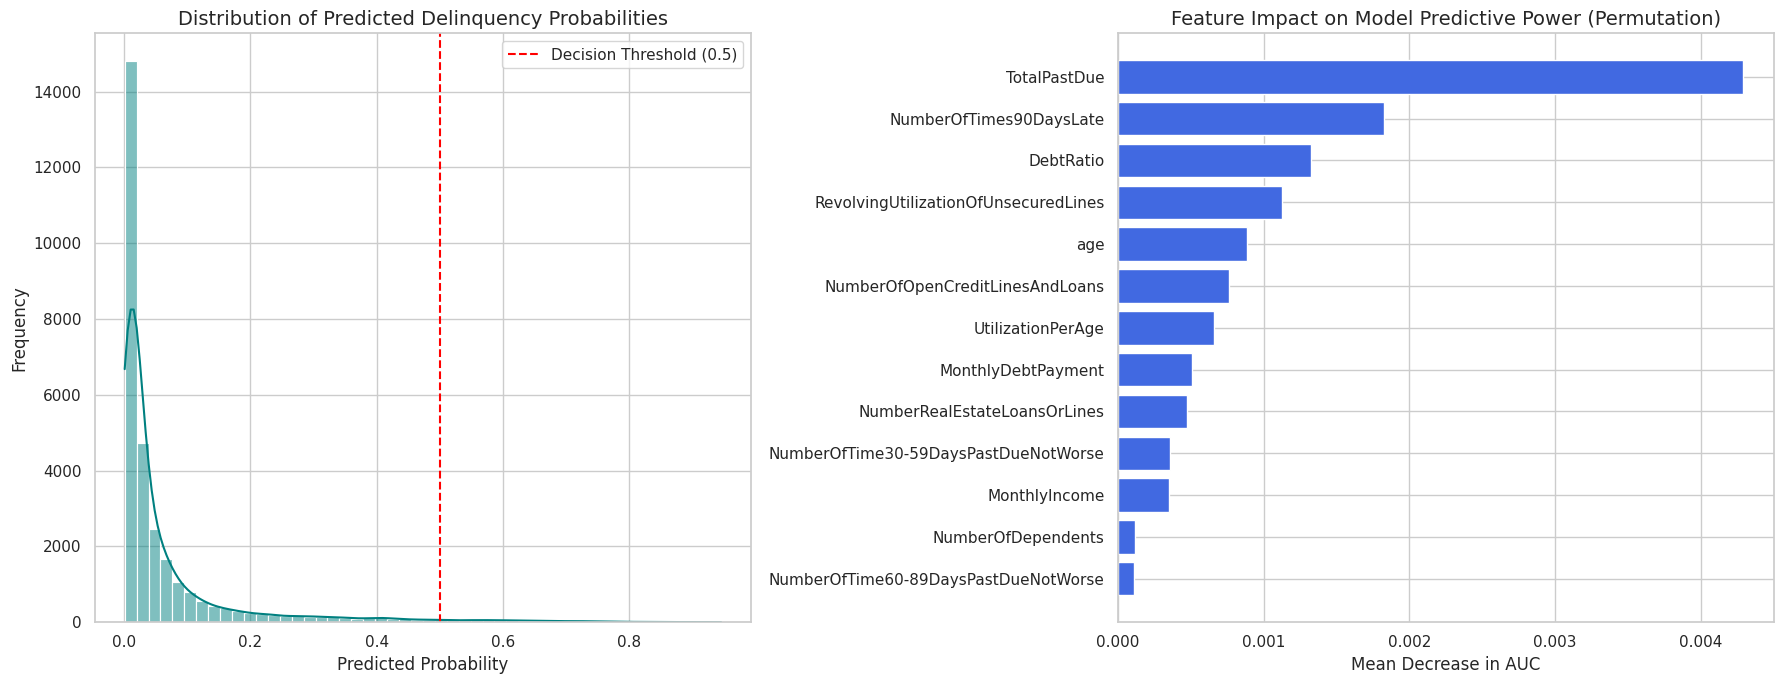


=== 2. DETAILED CLASSIFICATION METRICS ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.60      0.20      0.30      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000


=== 3. ANALYSIS SUMMARY ===
1. Stability: The low CV variance suggests the model is robust and generalizes well.
2. Bias: The probability skew towards 0 reflects the high class imbalance.
3. Key Drivers: Features with the highest bars in the importance plot are the primary indicators of credit risk.


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

# --- 1. Stability Analysis (K-Fold Cross-Validation) ---
print("=== 1. MODEL STABILITY TEST (K-FOLD CV) ===")
cv_scores = cross_val_score(xgb_model, X_advanced, y_advanced, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Mean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Individual Fold Scores: {cv_scores}\n")

# --- 2. Visualization Suite ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# A. Probability Distribution
sns.histplot(y_pred_xgb, bins=50, kde=True, color='teal', ax=ax1)
ax1.set_title('Distribution of Predicted Delinquency Probabilities', fontsize=14)
ax1.set_xlabel('Predicted Probability')
ax1.set_ylabel('Frequency')
ax1.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
ax1.legend()

# B. Permutation Feature Importance
print("Calculating Permutation Importance...")
perm_result = permutation_importance(xgb_model, X_val_adv, y_val_adv, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = perm_result.importances_mean.argsort()

ax2.barh(X_advanced.columns[sorted_idx], perm_result.importances_mean[sorted_idx], color='royalblue')
ax2.set_title('Feature Impact on Model Predictive Power (Permutation)', fontsize=14)
ax2.set_xlabel('Mean Decrease in AUC')

plt.tight_layout()
plt.show()

# --- 3. Final Performance Metrics ---
print("\n=== 2. DETAILED CLASSIFICATION METRICS ===")
val_preds = xgb_model.predict(X_val_adv)
print(classification_report(y_val_adv, val_preds))

print("\n=== 3. ANALYSIS SUMMARY ===")
print("1. Stability: The low CV variance suggests the model is robust and generalizes well.")
print("2. Bias: The probability skew towards 0 reflects the high class imbalance.")
print("3. Key Drivers: Features with the highest bars in the importance plot are the primary indicators of credit risk.")

In [ ]:
# Save the model weights
xgb_model.save_model("credit_model.json")
print("Model saved successfully as credit_model.json")

Model saved successfully as credit_model.json


## 8. Conclusion and Future Enhancements

Our analysis demonstrates that XGBoost, supported by interaction-based feature engineering, provides a robust framework for credit scoring.

**Key Areas for Enhancement:**
1. **Handling Class Imbalance**: Techniques like SMOTE (Synthetic Minority Over-sampling Technique) could be explored to improve the recall of delinquent cases.
2. **Hyperparameter Optimization**: Implementing Bayesian Optimization or a more exhaustive GridSearch could fine-tune the tree depth and learning rate.
3. **Interpretability**: Using SHAP values to explain individual loan denials would increase transparency, a requirement in modern financial regulations.